<a href="https://colab.research.google.com/github/Khizer45/Skyntri/blob/main/lab_linearreg_FA22_BSE_065.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Lab
**Submitted by:** Husnain Malik (FA22-BSE-065)

## Task 1 — Load the Data

In [1]:
import pandas as pd

data = {
    'Day': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Temperature': [22, 25, 28, 30, 33, 35, 38, 20, 27, 32],
    'CupsSold': [105, 120, 138, 152, 171, 185, 200, 90, 130, None]
}

df = pd.DataFrame(data)

print(df.head())
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

   Day  Temperature  CupsSold
0    1           22     105.0
1    2           25     120.0
2    3           28     138.0
3    4           30     152.0
4    5           33     171.0
Shape: (10, 3)
Columns: ['Day', 'Temperature', 'CupsSold']


## Task 2 — Plot the Data

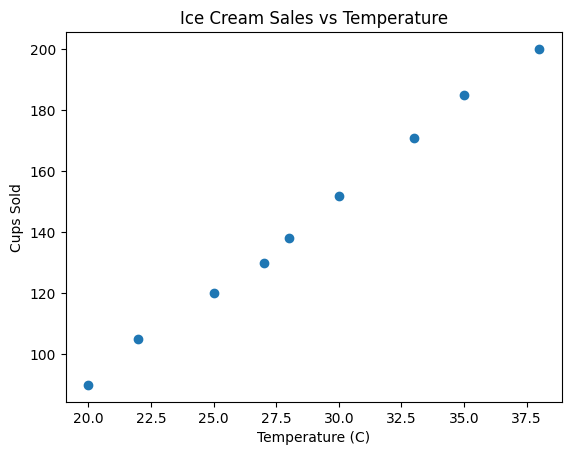

In [2]:
import matplotlib.pyplot as plt

train_df = df[:9]

plt.scatter(train_df['Temperature'], train_df['CupsSold'])
plt.xlabel('Temperature (C)')
plt.ylabel('Cups Sold')
plt.title('Ice Cream Sales vs Temperature')
plt.show()

# There is a clear positive relationship — as temperature increases, cups sold also increases.

## Task 3 — Train the Model

In [3]:
from sklearn.linear_model import LinearRegression

X_train = df[['Temperature']][:9]
y_train = df['CupsSold'][:9]

model = LinearRegression()
model.fit(X_train, y_train)

print('Slope:', model.coef_[0])
print('Intercept:', model.intercept_)

Slope: 6.173708920187793
Intercept: -33.535211267605604


## Task 4 — Make a Prediction

Predicted cups at 32C: 164.02347417840377


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


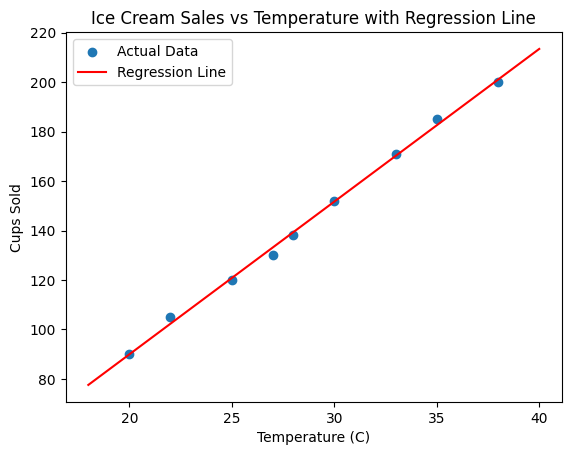

In [4]:
import numpy as np

pred = model.predict([[32]])
print('Predicted cups at 32C:', pred[0])

# Plot scatter + regression line
plt.scatter(train_df['Temperature'], train_df['CupsSold'], label='Actual Data')

x_line = np.linspace(18, 40, 100)
y_line = model.coef_[0] * x_line + model.intercept_
plt.plot(x_line, y_line, color='red', label='Regression Line')

plt.xlabel('Temperature (C)')
plt.ylabel('Cups Sold')
plt.title('Ice Cream Sales vs Temperature with Regression Line')
plt.legend()
plt.show()

## Task 5 — Evaluate the Model

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_train)

print('MAE:', mean_absolute_error(y_train, y_pred))
print('R2 Score:', r2_score(y_train, y_pred))

MAE: 1.4126238914971228
R2 Score: 0.9974518968010995


**Reflection:**

The R2 score is very close to 1.0, which means the regression line fits the training data almost perfectly. The MAE is also very low, meaning our predictions are off by only a small number of cups on average. This is a good model and the prediction for 32°C can be trusted, since temperature and sales follow a very consistent linear pattern in this dataset.